In [1]:
# Supervised Deep Learning for Fraud Detection
# Supervised Neural Network with Focal Loss
# Full implementation with Cost-Sensitive Evaluation and Error Analysis

import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    average_precision_score, roc_auc_score, 
    precision_recall_curve, precision_score, 
    recall_score, f1_score
)

try:
    current_dir = Path.cwd()
    if (current_dir / 'src').exists():
        PROJECT_ROOT = current_dir
    elif (current_dir.parent / 'src').exists():
        PROJECT_ROOT = current_dir.parent
    else:
        PROJECT_ROOT = Path.cwd().parent
except Exception:
    PROJECT_ROOT = Path.cwd()

print(f"Project root: {PROJECT_ROOT}")

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def load_processed_data(dataset='ieee'):
    data_dir = PROJECT_ROOT / 'data' / 'processed'
    train = pd.read_parquet(data_dir / f'{dataset}_train.parquet')
    test = pd.read_parquet(data_dir / f'{dataset}_test.parquet')
    with open(data_dir / 'dataset_info.json', 'r') as f:
        info = json.load(f)
    raw_cols = info[dataset]['raw_features']
    eng_cols = info[dataset]['engineered_features']
    all_cols = raw_cols + eng_cols
    return train, test, raw_cols, eng_cols, all_cols

train_ieee, test_ieee, raw_cols, eng_cols, all_cols = load_processed_data('ieee')

print(f"Raw features: {len(raw_cols)}")
print(f"Engineered features: {len(eng_cols)}")
print(f"Total features: {len(all_cols)}")
print(f"\nTrain shape: {train_ieee.shape}")
print(f"Test shape: {test_ieee.shape}")
print(f"Train fraud rate: {train_ieee['isFraud'].mean():.4f}")
print(f"Test fraud rate: {test_ieee['isFraud'].mean():.4f}")

# 1. Feature Preparation

X_train_raw = train_ieee[all_cols].values
X_test_raw = test_ieee[all_cols].values
y_train = train_ieee['isFraud'].values
y_test = test_ieee['isFraud'].values

print(f"\nX_train shape: {X_train_raw.shape}")
print(f"X_test shape: {X_test_raw.shape}")

print(f"Train missing values: {np.isnan(X_train_raw).sum()}")
print(f"Test missing values: {np.isnan(X_test_raw).sum()}")

if np.isnan(X_train_raw).sum() > 0:
    print("Filling missing values...")
    for i in range(X_train_raw.shape[1]):
        col_median = np.nanmedian(X_train_raw[:, i])
        X_train_raw[np.isnan(X_train_raw[:, i]), i] = col_median
        X_test_raw[np.isnan(X_test_raw[:, i]), i] = col_median

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"X_train shape after scaling: {X_train.shape}")
print(f"X_test shape after scaling: {X_test.shape}")






Project root: /Users/mac/Desktop/DSS5104_Assignment2
PyTorch version: 2.11.0
Using device: cpu
Raw features: 47
Engineered features: 17
Total features: 64

Train shape: (472432, 470)
Test shape: (118108, 470)
Train fraud rate: 0.0351
Test fraud rate: 0.0344

X_train shape: (472432, 64)
X_test shape: (118108, 64)
Train missing values: 3433954
Test missing values: 817332
Filling missing values...
X_train shape after scaling: (472432, 64)
X_test shape after scaling: (118108, 64)


In [2]:
# 2. Define Model

class FraudDetectionNet(nn.Module):
    def __init__(self, input_dim, hidden_dims=[256, 128, 64, 32], dropout_rate=0.3):
        super(FraudDetectionNet, self).__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)


class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        bce_loss = nn.functional.binary_cross_entropy(inputs, targets, reduction='none')
        p_t = inputs * targets + (1 - inputs) * (1 - targets)
        focal_weight = (1 - p_t) ** self.gamma
        alpha_weight = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        loss = alpha_weight * focal_weight * bce_loss
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss


In [3]:

# 3. Training Function

def train_model(X_train, y_train, X_val, y_val, input_dim,
                epochs=200, batch_size=4096, lr=0.001,
                patience=20, verbose=True):
    
    X_train_tensor = torch.FloatTensor(X_train).to(device)
    y_train_tensor = torch.FloatTensor(y_train).to(device)
    X_val_tensor = torch.FloatTensor(X_val).to(device)
    y_val_tensor = torch.FloatTensor(y_val).to(device)
    
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    model = FraudDetectionNet(input_dim).to(device)
    criterion = FocalLoss(alpha=0.75, gamma=2.0)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
    
    best_val_loss = float('inf')
    patience_counter = 0
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X).squeeze()
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item() * batch_X.size(0)
        
        epoch_train_loss /= len(X_train)
        train_losses.append(epoch_train_loss)
        
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor).squeeze()
            val_loss = criterion(val_outputs, y_val_tensor).item()
        val_losses.append(val_loss)
        
        scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch+1}")
            break
        
        if verbose and (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {epoch_train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    model.load_state_dict(best_model_state)
    return model, train_losses, val_losses


In [4]:
# 4. Train Model

val_size = int(len(X_train) * 0.2)
X_train_sub = X_train[:-val_size]
y_train_sub = y_train[:-val_size]
X_val = X_train[-val_size:]
y_val = y_train[-val_size:]

print(f"\nTraining set size: {len(X_train_sub):,}")
print(f"Validation set size: {len(X_val):,}")
print(f"Input dimension: {X_train.shape[1]}")

print("\n" + "="*60)
print("Training Supervised Neural Network")
print("="*60)

model, train_losses, val_losses = train_model(
    X_train_sub, y_train_sub, X_val, y_val,
    input_dim=X_train.shape[1],
    epochs=200,
    batch_size=4096,
    lr=0.001,
    patience=20,
    verbose=True
)



Training set size: 377,946
Validation set size: 94,486
Input dimension: 64

Training Supervised Neural Network
Epoch 20/200, Train Loss: 0.0126, Val Loss: 0.0143
Epoch 40/200, Train Loss: 0.0111, Val Loss: 0.0142
Epoch 60/200, Train Loss: 0.0098, Val Loss: 0.0145
Early stopping at epoch 61


In [5]:
# 5. Predict and Basic Metrics
# ============================================================

X_test_tensor = torch.FloatTensor(X_test).to(device)
model.eval()
with torch.no_grad():
    y_pred_proba = model(X_test_tensor).squeeze().cpu().numpy()

auprc = average_precision_score(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nTest Results:")
print(f"  AUPRC: {auprc:.4f}")
print(f"  ROC AUC: {roc_auc:.4f}")



Test Results:
  AUPRC: 0.4887
  ROC AUC: 0.9046


In [6]:
# 6. Cost-Sensitive Evaluation

def find_cost_optimal_threshold(y_true, y_scores, fn_cost=500, fp_cost=2):
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    costs = []
    f1_scores = []
    
    for t in thresholds:
        y_pred = (y_scores >= t).astype(int)
        tp = np.sum((y_true == 1) & (y_pred == 1))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        total_cost = fn * fn_cost + fp * fp_cost
        costs.append(total_cost)
        p = tp / (tp + fp + 1e-9)
        r = tp / (tp + fn + 1e-9)
        f1_scores.append(2 * p * r / (p + r + 1e-9) if (p + r) > 0 else 0)
    
    best_idx = np.argmin(costs)
    best_threshold = thresholds[best_idx]
    min_cost = costs[best_idx]
    f1_best_idx = np.argmax(f1_scores)
    f1_optimal_threshold = thresholds[f1_best_idx]
    
    return best_threshold, min_cost, f1_optimal_threshold, thresholds, costs, f1_scores

cost_threshold, min_cost, f1_threshold, thresholds, costs, f1_scores = find_cost_optimal_threshold(
    y_test, y_pred_proba, fn_cost=500, fp_cost=2
)

print("\n" + "="*60)
print("Cost-Sensitive Evaluation (FN=$500, FP=$2)")
print("="*60)
print(f"\nSupervised Neural Network:")
print(f"  Cost-optimal threshold: {cost_threshold:.4f}")
print(f"  F1-optimal threshold: {f1_threshold:.4f}")
print(f"  Minimum total cost: ${min_cost:,.2f}")
print(f"  Difference (Cost vs F1): {abs(cost_threshold - f1_threshold):.4f}")


Cost-Sensitive Evaluation (FN=$500, FP=$2)

Supervised Neural Network:
  Cost-optimal threshold: 0.0789
  F1-optimal threshold: 0.4804
  Minimum total cost: $190,470.00
  Difference (Cost vs F1): 0.4016


In [7]:

# 7. Evaluation at Cost-Optimal Threshold

y_pred_optimal = (y_pred_proba >= cost_threshold).astype(int)

precision_opt = precision_score(y_test, y_pred_optimal)
recall_opt = recall_score(y_test, y_pred_optimal)
f1_opt = f1_score(y_test, y_pred_optimal)

print("\n" + "="*60)
print(f"Evaluation at Cost-Optimal Threshold ({cost_threshold:.4f})")
print("="*60)
print(f"  AUPRC: {auprc:.4f}")
print(f"  Precision: {precision_opt:.4f}")
print(f"  Recall: {recall_opt:.4f}")
print(f"  F1: {f1_opt:.4f}")

# 8. Error Analysis

print("\n" + "="*60)
print("Error Analysis")
print("="*60)

fp_idx = np.where((y_test == 0) & (y_pred_optimal == 1))[0]
fn_idx = np.where((y_test == 1) & (y_pred_optimal == 0))[0]
tp_idx = np.where((y_test == 1) & (y_pred_optimal == 1))[0]

print(f"False Positives (Normal flagged as Fraud): {len(fp_idx)}")
print(f"False Negatives (Fraud missed): {len(fn_idx)}")
print(f"True Positives (Fraud caught): {len(tp_idx)}")

print("\n--- False Positives Analysis (First 10 samples) ---")
if len(fp_idx) > 0:
    sample_fp = test_ieee.iloc[fp_idx[:min(10, len(fp_idx))]]
    if 'TransactionAmt' in sample_fp.columns:
        print(f"Transaction amounts: min=${sample_fp['TransactionAmt'].min():.2f}, "
              f"max=${sample_fp['TransactionAmt'].max():.2f}, "
              f"mean=${sample_fp['TransactionAmt'].mean():.2f}")

print("\n--- False Negatives Analysis (First 10 samples) ---")
if len(fn_idx) > 0:
    sample_fn = test_ieee.iloc[fn_idx[:min(10, len(fn_idx))]]
    if 'TransactionAmt' in sample_fn.columns:
        print(f"Transaction amounts: min=${sample_fn['TransactionAmt'].min():.2f}, "
              f"max=${sample_fn['TransactionAmt'].max():.2f}, "
              f"mean=${sample_fn['TransactionAmt'].mean():.2f}")



Evaluation at Cost-Optimal Threshold (0.0789)
  AUPRC: 0.4887
  Precision: 0.0520
  Recall: 0.9776
  F1: 0.0987

Error Analysis
False Positives (Normal flagged as Fraud): 72485
False Negatives (Fraud missed): 91
True Positives (Fraud caught): 3973

--- False Positives Analysis (First 10 samples) ---
Transaction amounts: min=$20.00, max=$136.96, mean=$54.85

--- False Negatives Analysis (First 10 samples) ---
Transaction amounts: min=$25.00, max=$299.95, mean=$105.04


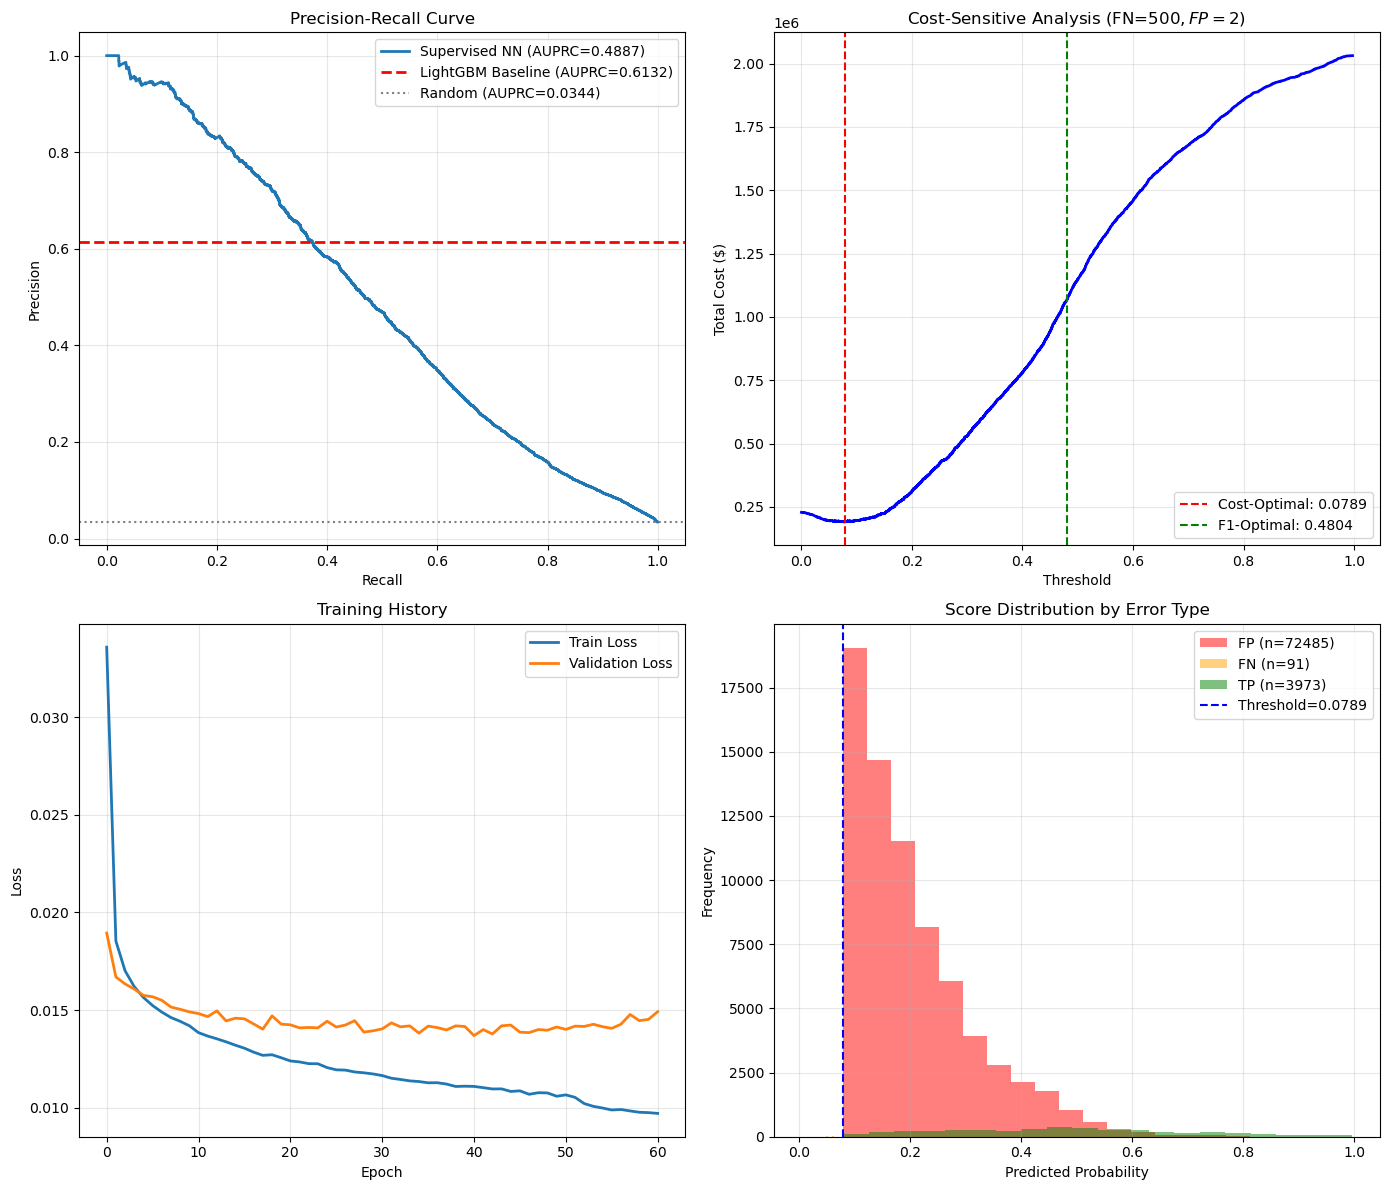


Results Summary
                    Model    AUPRC  ROC AUC Cost-Optimal Threshold Min Total Cost Precision@Optimal Recall@Optimal F1@Optimal
Supervised Neural Network 0.488745 0.904608                 0.0789    $190,470.00            0.0520         0.9776     0.0987
        LightGBM Baseline 0.613200 0.943100                 0.0708       $148,464            0.0673         0.9813     0.1259


In [8]:

# 9. Visualization (4 subplots)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 9.1 PR Curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
axes[0, 0].plot(recall_curve, precision_curve, linewidth=2, 
                label=f'Supervised NN (AUPRC={auprc:.4f})')
axes[0, 0].axhline(y=0.6132, color='red', linestyle='--', linewidth=2,
                   label=f'LightGBM Baseline (AUPRC=0.6132)')
axes[0, 0].axhline(y=y_test.mean(), color='gray', linestyle=':', linewidth=1.5,
                   label=f'Random (AUPRC={y_test.mean():.4f})')
axes[0, 0].set_xlabel('Recall')
axes[0, 0].set_ylabel('Precision')
axes[0, 0].set_title('Precision-Recall Curve')
axes[0, 0].legend(loc='upper right')
axes[0, 0].grid(True, alpha=0.3)

# 9.2 Cost Curve
axes[0, 1].plot(thresholds, costs, 'b-', linewidth=2)
axes[0, 1].axvline(x=cost_threshold, color='red', linestyle='--', 
                   label=f'Cost-Optimal: {cost_threshold:.4f}')
axes[0, 1].axvline(x=f1_threshold, color='green', linestyle='--', 
                   label=f'F1-Optimal: {f1_threshold:.4f}')
axes[0, 1].set_xlabel('Threshold')
axes[0, 1].set_ylabel('Total Cost ($)')
axes[0, 1].set_title('Cost-Sensitive Analysis (FN=$500, FP=$2)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 9.3 Training History
axes[1, 0].plot(train_losses, label='Train Loss', linewidth=2)
axes[1, 0].plot(val_losses, label='Validation Loss', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('Training History')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 9.4 Score Distribution by Error Type
fp_scores = y_pred_proba[fp_idx] if len(fp_idx) > 0 else []
fn_scores = y_pred_proba[fn_idx] if len(fn_idx) > 0 else []
tp_scores = y_pred_proba[tp_idx] if len(tp_idx) > 0 else []

axes[1, 1].hist(fp_scores, bins=20, alpha=0.5, label=f'FP (n={len(fp_idx)})', color='red')
axes[1, 1].hist(fn_scores, bins=20, alpha=0.5, label=f'FN (n={len(fn_idx)})', color='orange')
axes[1, 1].hist(tp_scores, bins=20, alpha=0.5, label=f'TP (n={len(tp_idx)})', color='green')
axes[1, 1].axvline(x=cost_threshold, color='blue', linestyle='--', 
                   label=f'Threshold={cost_threshold:.4f}')
axes[1, 1].set_xlabel('Predicted Probability')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Score Distribution by Error Type')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data/processed' / 'supervised_nn_complete_results.png', dpi=150, bbox_inches='tight')
plt.show()

# 10. Results Summary

results_summary = pd.DataFrame({
    'Model': ['Supervised Neural Network', 'LightGBM Baseline'],
    'AUPRC': [auprc, 0.6132],
    'ROC AUC': [roc_auc, 0.9431],
    'Cost-Optimal Threshold': [f"{cost_threshold:.4f}", "0.0708"],
    'Min Total Cost': [f"${min_cost:,.2f}", "$148,464"],
    'Precision@Optimal': [f"{precision_opt:.4f}", "0.0673"],
    'Recall@Optimal': [f"{recall_opt:.4f}", "0.9813"],
    'F1@Optimal': [f"{f1_opt:.4f}", "0.1259"]
})

print("\n" + "="*60)
print("Results Summary")
print("="*60)
print(results_summary.to_string(index=False))